# EDA: HAM10000 (метадані діагностики шкірних утворень)

Первинний аналіз даних для класифікації діагнозу (`dx`) за метаданими: вік, стать, локалізація.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
%matplotlib inline

In [4]:
# Шлях до даних (з кореня проєкту)
project_root = Path("/Users/ssopr/Desktop/MLflow/MLflow")
path_raw = project_root / "data" / "raw" / "HAM10000_metadata.csv"
path_alt = project_root / "data" / "HAM10000_metadata.csv"
path_csv = path_raw if path_raw.exists() else path_alt
df = pd.read_csv(path_csv)
df.head(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back


## Базова інформація про датасет

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [6]:
df.describe(include="all")

,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0003789,ISIC_0027419,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


## Розподіл цільової змінної (діагноз, dx)

In [7]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

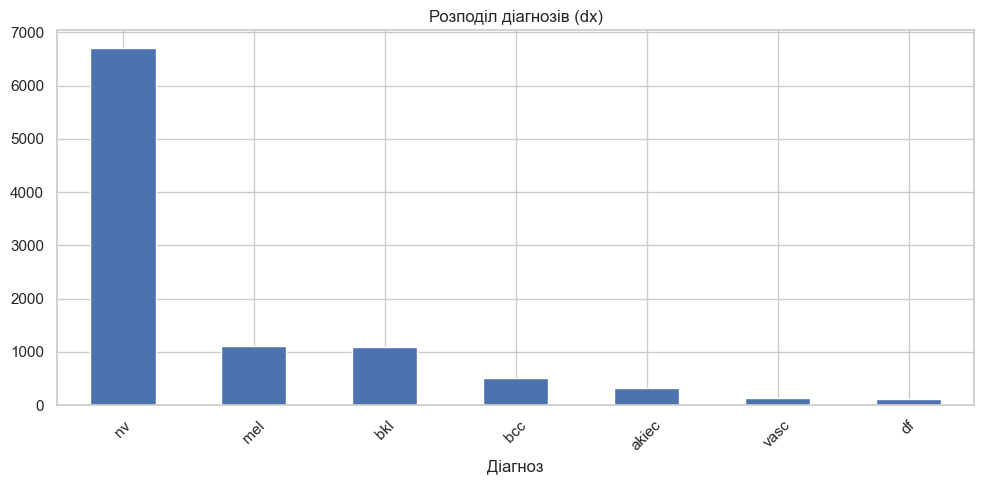

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
df["dx"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Розподіл діагнозів (dx)")
ax.set_xlabel("Діагноз")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Стать та локалізація

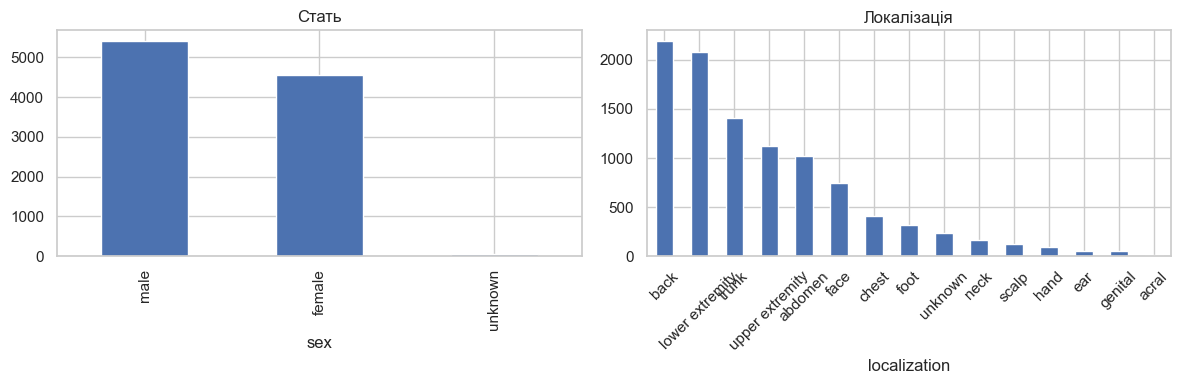

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["sex"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Стать")
df["localization"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Локалізація")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Вік

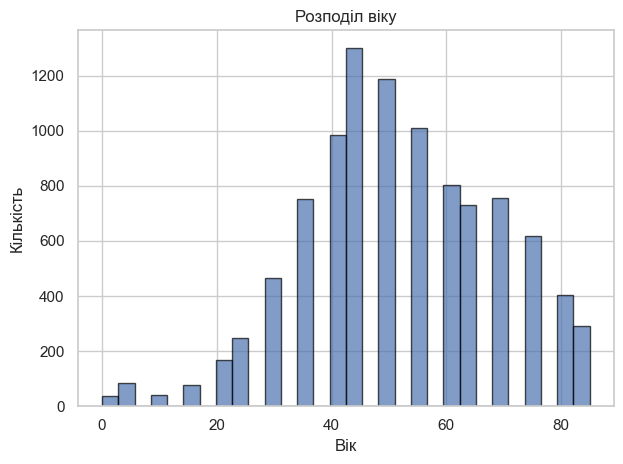

In [10]:
df["age"].hist(bins=30, edgecolor="black", alpha=0.7)
plt.title("Розподіл віку")
plt.xlabel("Вік")
plt.ylabel("Кількість")
plt.tight_layout()
plt.show()

## Пропуски та дублікати

In [11]:
print("Пропуски:", df.isnull().sum().to_string())
print("\nДублікати за image_id:", df.duplicated(subset=["image_id"]).sum())

Пропуски: lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0

Дублікати за image_id: 0


## Тип діагностики (dx_type)

Розподіл за способом встановлення діагнозу: histo, confocal, follow_up тощо.

In [ ]:
df["dx_type"].value_counts()

In [ ]:
df["dx_type"].value_counts().plot(kind="bar", figsize=(8, 3))
plt.title("Тип діагностики (dx_type)")
plt.xlabel("dx_type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Вік за діагнозом (dx)

Boxplot: розподіл віку по класах діагнозу — допомагає побачити, чи вік пов’язаний із типом утворення.

In [ ]:
df_age = df.dropna(subset=["age"])
sns.boxplot(data=df_age, x="dx", y="age")
plt.title("Вік за діагнозом (dx)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Таблиця спряженості: стать × діагноз

Перевірка зв’язку статі з типом діагнозу.

In [ ]:
pd.crosstab(df["sex"], df["dx"], margins=True)

## Кореляція ознак (після кодування)

Числові ознаки для моделі: age, sex_enc, loc_enc. Теплова карта кореляцій.

In [ ]:
from sklearn.preprocessing import LabelEncoder
df_enc = df.copy()
df_enc["age"] = pd.to_numeric(df_enc["age"], errors="coerce").fillna(df_enc["age"].median())
df_enc["sex_enc"] = LabelEncoder().fit_transform(df_enc["sex"].astype(str))
df_enc["loc_enc"] = LabelEncoder().fit_transform(df_enc["localization"].astype(str))
corr = df_enc[["age", "sex_enc", "loc_enc"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Кореляція ознак (age, sex_enc, loc_enc)")
plt.tight_layout()
plt.show()

## Аналіз зображень

Перегляд зображень уражень (дерматоскопія) та їх зв'язок із діагнозом. Використовуємо папки `HAM10000_images_part_1/`, `part_2/` та попередньо оброблені зображення з hmnist (28×28).

In [ ]:
# Шляхи до папок з оригінальними зображеннями
img_dir_1 = project_root / "data" / "raw" / "HAM10000_images_part_1"
img_dir_2 = project_root / "data" / "raw" / "HAM10000_images_part_2"

def get_image_path(image_id: str):
    for d in (img_dir_1, img_dir_2):
        if d.exists():
            p = d / f"{image_id}.jpg"
            if p.exists():
                return p
    return None

# По одному прикладу зображення на кожен діагноз (dx)
samples = df.groupby("dx", as_index=False).first()[["dx", "image_id"]]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for i, (_, row) in enumerate(samples.iterrows()):
    path = get_image_path(row["image_id"])
    ax = axes[i]
    if path is not None:
        img = plt.imread(path)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center")
    ax.set_title(f"dx = {row['dx']}")
    ax.axis("off")
axes[-1].axis("off")
plt.suptitle("Приклад зображень по діагнозах (dx)")
plt.tight_layout()
plt.show()

In [ ]:
# hmnist: зображення 28×28 (grayscale), рядки збігаються з метаданими за індексом
path_hmnist = project_root / "data" / "raw" / "hmnist_28_28_L.csv"
if path_hmnist.exists():
    hmnist = pd.read_csv(path_hmnist)
    pixel_cols = [c for c in hmnist.columns if c.startswith("pixel")]
    # Середнє зображення по класу dx (індекс = індекс в df)
    df_hm = df[["dx"]].copy()
    df_hm["idx"] = range(len(df_hm))
    for c in pixel_cols:
        df_hm[c] = hmnist[c].values
    mean_by_dx = df_hm.groupby("dx")[pixel_cols].mean()
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()
    for i, (dx_val, row) in enumerate(mean_by_dx.iterrows()):
        img = row.values.reshape(28, 28)
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"dx = {dx_val}\n(середнє)")
        axes[i].axis("off")
    axes[-1].axis("off")
    plt.suptitle("Середнє зображення 28×28 по діагнозах (hmnist)")
    plt.tight_layout()
    plt.show()
else:
    print("hmnist_28_28_L.csv не знайдено — пропуск візуалізації hmnist.")

## Висновки EDA

- Датасет містить метадані зображень: діагноз (`dx`), вік, стать, локалізація.
- Класів діагнозу 7; розподіл нерівномірний (наприклад, nv переважає).
- Для baseline-моделі можна використати ознаки: age, sex (encoded), localization (encoded).